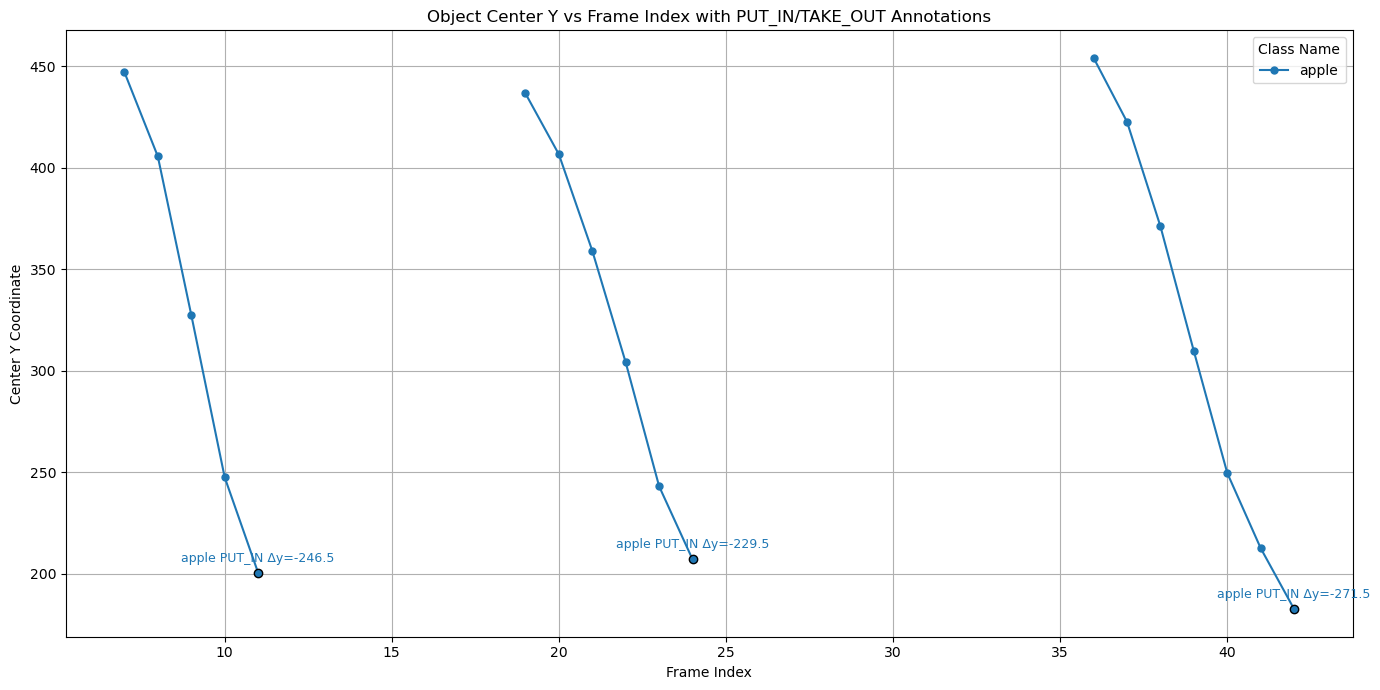

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

from src.data_detection_layer.loader import load_and_validate_vision_json
from src.data_detection_layer.vision_to_events import analyze_operation_segments

# ===== Notebook Inputs =====
session_id = "session_11111111_111111"
start_index = 0
end_index = None  # Set to an int to cap the plotted frame range.

# ===== Load Raw JSON For Plotting =====
json_path = Path(f"data/sessions/{session_id}/vision.json")
with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

frames = data["samples"]
all_indices = [frame["index"] for frame in frames if "index" in frame]
if not all_indices:
    raise ValueError(f"No frame indices found in {json_path}")
if end_index is None:
    end_index = max(all_indices)

selected_frames = [
    frame
    for frame in frames
    if start_index <= frame.get("index", -1) <= end_index
]

# ===== Shared Event Logic =====
session = load_and_validate_vision_json(str(json_path))
segment_decisions = analyze_operation_segments(session)

# ===== Collect Per-Class Y Traces =====
def build_plot_segments(samples, start_idx, end_idx):
    traces_by_class = defaultdict(list)

    for frame in samples:
        frame_index = frame.get("index")
        if frame_index is None or not (start_idx <= frame_index <= end_idx):
            continue

        per_class_points = defaultdict(list)
        for detection in frame.get("detections", []):
            center = detection.get("center") or {}
            if "y" not in center:
                continue
            per_class_points[detection["class_name"]].append(float(center["y"]))

        for class_name, y_values in per_class_points.items():
            traces_by_class[class_name].append((frame_index, y_values))

    segmented_traces = {}
    for class_name, frame_points in traces_by_class.items():
        frame_points.sort(key=lambda item: item[0])
        class_segments = []
        current_x = []
        current_y = []
        previous_frame = None

        for frame_index, y_values in frame_points:
            if previous_frame is not None and frame_index - previous_frame > 1:
                class_segments.append((current_x, current_y))
                current_x = []
                current_y = []

            for y_value in y_values:
                current_x.append(frame_index)
                current_y.append(y_value)

            previous_frame = frame_index

        if current_x:
            class_segments.append((current_x, current_y))

        segmented_traces[class_name] = class_segments

    return segmented_traces


plot_segments = build_plot_segments(selected_frames, start_index, end_index)
class_names = sorted(plot_segments)
colors = plt.get_cmap("tab10", max(len(class_names), 1))
color_by_class = {
    class_name: colors(i % max(len(class_names), 1))
    for i, class_name in enumerate(class_names)
}

# ===== Plot =====
plt.figure(figsize=(14, 7))
for class_name in class_names:
    class_segments = plot_segments[class_name]
    color = color_by_class[class_name]
    for segment_index, (x_values, y_values) in enumerate(class_segments):
        label = class_name if segment_index == 0 else None
        plt.plot(
            x_values,
            y_values,
            marker="o",
            linestyle="-",
            linewidth=1.5,
            markersize=5,
            color=color,
            label=label,
        )

for decision in segment_decisions:
    if decision.operation is None:
        continue
    if not (start_index <= decision.last_frame_index <= end_index):
        continue

    color = color_by_class.get(decision.class_name, "black")
    plt.scatter(
        [decision.last_frame_index],
        [decision.last_y],
        color=color,
        edgecolors="black",
        zorder=5,
    )
    plt.annotate(
        f"{decision.class_name} {decision.operation} Δy={decision.delta_y:.1f}",
        (decision.last_frame_index, decision.last_y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color=color,
        fontsize=9,
    )

plt.xlabel("Frame Index")
plt.ylabel("Center Y Coordinate")
plt.title("Object Center Y vs Frame Index with PUT_IN/TAKE_OUT Annotations")
plt.grid(True)
if class_names:
    plt.legend(title="Class Name")
plt.tight_layout()
plt.show()
